<a href="https://colab.research.google.com/github/Zuhdiaja/244107020017_Machine_Learning/blob/main/JS04/JS4_TugasPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**TUGAS 1 K-Means**




In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML 2026/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


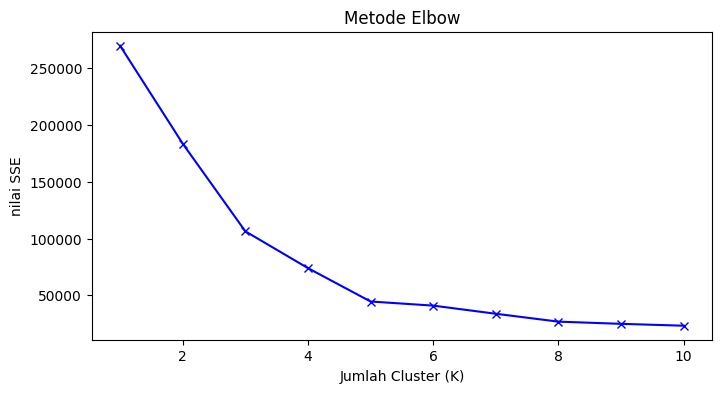

In [4]:
X_kmeans = df.iloc[:, [3,4]].values #seleksi fitur klom 3 & 4

# k terbaik metode elbow
sse = []
K_range = range(1,11)
for  k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_kmeans)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, sse, marker='x', linestyle='-', color='b')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('nilai SSE')
plt.title('Metode Elbow')
plt.show()

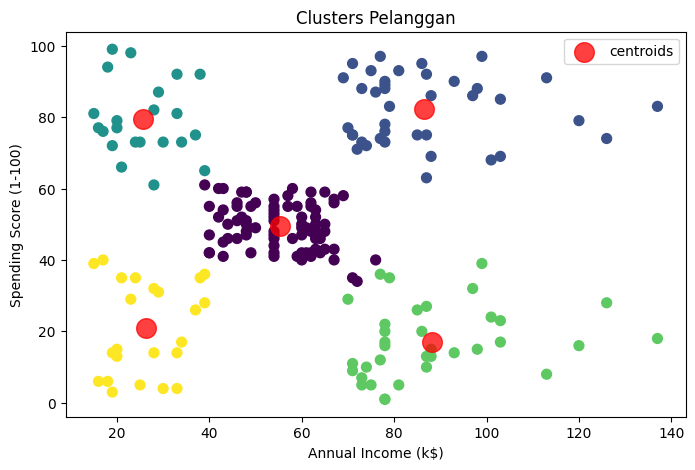

In [9]:
# tekukan tajam di k=5, model kmeans dgn k=5
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
y_kmeans = kmeans_model.fit_predict(X_kmeans)

# visualisasi
plt.figure(figsize=(8,5))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans_model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red',alpha=0.75, marker='o', label='centroids')
plt.title('Clusters Pelanggan')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

##**TUGAS 1 DBscan**


In [11]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn import metrics

In [38]:
# dataset make_moons dan normalisai
X_moons, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X_moons)

#jalankan
db = DBSCAN(eps=0.2, min_samples=5,).fit(X_scaled)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("HASIL DBSCAN (eps=0.2, min_samples=5")
print(f"Jumlah klaster: {n_clusters_}")
print(f"Jumlah titik noise: {n_noise_}")

HASIL DBSCAN (eps=0.2, min_samples=5
Jumlah klaster: 2
Jumlah titik noise: 0


In [43]:
# evaluasi dgn matrik

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
# silhouette minimal 2 klaster dan tidak lebih dari (n_samples - 1)
print(f"Silhouette: {metrics.silhouette_score(X_scaled, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette: 0.391
Silhouette Coefficient: 0.391


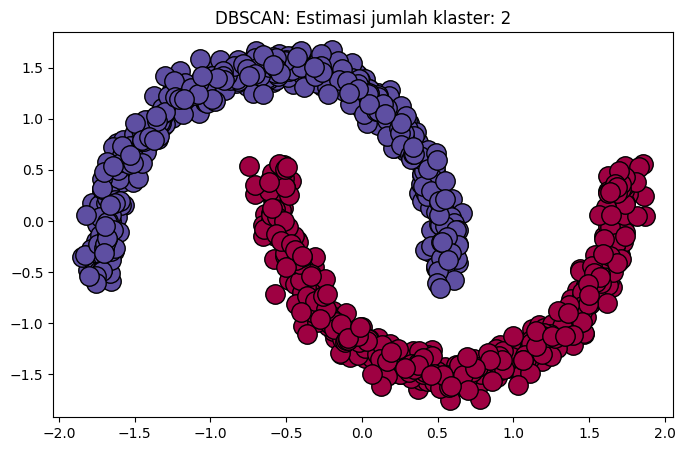

In [55]:
# visualisasi DBSCAN

unique_labels = set(labels)
core_sample_mask = np.zeros_like(db.labels_, dtype=bool)
core_sample_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 5))
for k, col in zip(unique_labels, colors):
  if k == -1:
    col = [0,0,0,1]

  class_member_mask = (labels == k)

#titik besar
  xy = X_scaled[class_member_mask & core_sample_mask]
  plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=14)

#titik kecil
  xy = X_scaled[class_member_mask & ~core_sample_mask]
  plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)

plt.title(f'DBSCAN: Estimasi jumlah klaster: {n_clusters_}')
plt.show()

In [64]:
# Eksperimen eps = 0.05, 0.1, 0.3, 0.5
# min_samples = 3, 10, 20

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print(f"{'eps':<5} | {'min_sample':<12} | {'Klaster':<8} | {'Noises':<6} | {'V-measure':<10} | {'silhouette'}")
print("-" * 65)

for eps_val in eps_values:
  for min_samp in min_samples_values:
    db_exp = DBSCAN(eps=eps_val, min_samples=min_samp).fit(X_scaled)
    lbls = db_exp.labels_

    n_clust = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_ns = list(lbls).count(-1)

    #kalkulasi evaluasi
    v_means = metrics.v_measure_score(labels_true, lbls)
    silh = metrics.silhouette_score(X_scaled, lbls) if n_clust > 1 else 0.0

    print(f"{eps_val:<5} | {min_samp:<12} | {n_clust:<8} | {n_ns:<6} | {v_means:<10.3f} | {silh:.3f}")

eps   | min_sample   | Klaster  | Noises | V-measure  | silhouette
-----------------------------------------------------------------
0.05  | 3            | 69       | 186    | 0.257      | 0.113
0.05  | 10           | 3        | 970    | 0.049      | -0.294
0.05  | 20           | 0        | 1000   | 0.000      | 0.000
0.1   | 3            | 2        | 14     | 0.943      | 0.252
0.1   | 10           | 7        | 57     | 0.571      | 0.162
0.1   | 20           | 6        | 850    | 0.155      | -0.360
0.3   | 3            | 2        | 0      | 1.000      | 0.391
0.3   | 10           | 2        | 0      | 1.000      | 0.391
0.3   | 20           | 2        | 0      | 1.000      | 0.391
0.5   | 3            | 2        | 0      | 1.000      | 0.391
0.5   | 10           | 2        | 0      | 1.000      | 0.391
0.5   | 20           | 2        | 0      | 1.000      | 0.391
